In [4]:
import Simulated_annealing
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import random

class Image_Denoising(Simulated_annealing.State):
    
    def __init__(self, image : np.ndarray, smoothing_bias : float, change_magnitude = 1):
        self.image = image.copy()
        if self.image.dtype == np.float32 or self.image.dtype == np.float64:
            self.image = (self.image * 255).astype(np.int16)
        self.state = self.image
        self.y_len, self.x_len, self.channels = image.shape
        self.smoothing_bias = smoothing_bias
        self.original_bias = 1 - smoothing_bias
        self.change_magnitude = change_magnitude
    
    def get_neighbour(self):
        i = random.randrange(0, self.y_len)
        j = random.randrange(0, self.x_len)

        v = np.zeros(shape = self.channels)
        
        for a in range(self.channels):
            v[a] = random.randrange(int(max(self.state[i, j, a] - self.change_magnitude, 0)), int(min(self.state[i, j, a] + self.change_magnitude, 256)))

        return (i * self.x_len + j, v)
    
    def cost(self, state = None):
        if state == None:
            state = self.state
        
        diff_cost = np.linalg.norm(state - self.image)**2 / (self.x_len * self.y_len)
        return diff_cost
    
    def cost_change(self, idx, change):
        i = idx // self.x_len
        j = idx % self.x_len

        curr_val = self.state[i, j]
        new_val = change

        old_cost = (np.linalg.norm(curr_val - self.image[i, j]) ** 2)

        smoothing_cost = 0
        n_neighbours = 0

        if (i + 1 < self.y_len):
            smoothing_cost += np.linalg.norm(curr_val - self.state[i+1, j])**2
            n_neighbours += 1
        if (i - 1 >= 0):
            smoothing_cost += np.linalg.norm(curr_val - self.state[i-1, j])**2
            n_neighbours += 1
        if (j + 1 < self.x_len):
            smoothing_cost += np.linalg.norm(curr_val - self.state[i, j+1])**2
            n_neighbours += 1
        if (j - 1 >= 0):
            smoothing_cost += np.linalg.norm(curr_val - self.state[i, j-1])**2
            n_neighbours += 1
        
        smoothing_cost /= n_neighbours

        old_cost = self.original_bias * old_cost + self.smoothing_bias * smoothing_cost


        new_cost = (np.linalg.norm(new_val - self.image[i, j]) ** 2)

        smoothing_cost = 0
        n_neighbours = 0

        if (i + 1 < self.y_len):
            smoothing_cost += np.linalg.norm(new_val - self.state[i+1, j]) ** 2
            n_neighbours += 1
        if (i - 1 >= 0):
            smoothing_cost += np.linalg.norm(new_val - self.state[i-1, j]) ** 2
            n_neighbours += 1
        if (j + 1 < self.x_len):
            smoothing_cost += np.linalg.norm(new_val - self.state[i, j+1]) ** 2
            n_neighbours += 1
        if (j - 1 >= 0):
            smoothing_cost += np.linalg.norm(new_val - self.state[i, j-1]) ** 2
            n_neighbours += 1
        
        smoothing_cost /= n_neighbours

        new_cost = self.original_bias * new_cost + self.smoothing_bias * smoothing_cost

        return (new_cost - old_cost)
    
    def update(self, idx, change):
        i = idx // self.x_len
        j = idx % self.x_len

        self.state[i, j] = change
        return


Completed Annealing


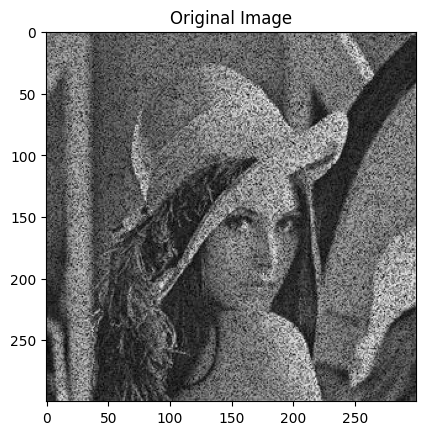

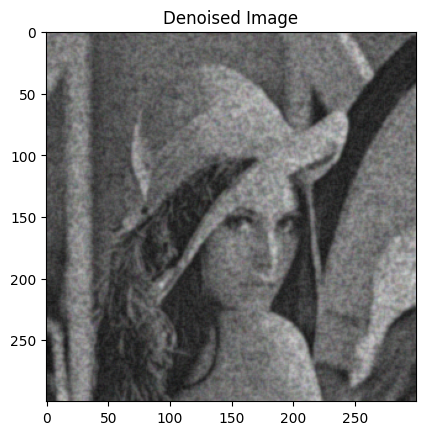

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-160..142].


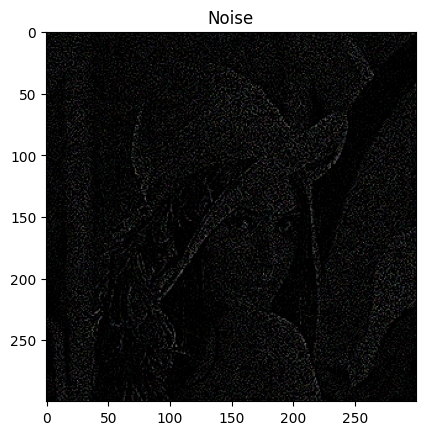

In [5]:
image_path = "Files/Noisy_image_bw_2.png"
image = (mpimg.imread(image_path) * 255).astype(np.int16)

Image_state = Image_Denoising(image, smoothing_bias = 0.3, change_magnitude = 20)
Solver = Simulated_annealing.Annealer(Image_state, initial_temp= 100, temperature_schedule = 'exponential', scheduling_constant = 0.001)

Solver.anneal(unchanged_threshold = 10000)
print("Completed Annealing")

denoised_image = Image_state.state

plt.imshow(image)
plt.title("Original Image")
plt.show()

plt.imshow(denoised_image)
plt.title("Denoised Image")
plt.show()

plt.imshow(image - denoised_image)
plt.title("Noise")
plt.show()